In [3]:
import pandas as pd
import matplotlib.pyplot as plt

paper = pd.read_csv('trees.csv')
existant = paper.dropna()
alive = existant.loc[existant['condition'] != 'Dead']
# Drops dead, inapplicable, and nonexistant trees from the dataset.

# As no trees in this dataset are outside of official neighborhoods,
# none need to be dropped.

data = {
    "neighborhood": alive['neighborhood'].unique(),
    "trees": 0, # Total trees in the neighborhood.
    "score": 0.0, # Condition-adjusted tree score.
    "bad": 0, # Trees in Critical or Poor condition
    "okay": 0, # ditto Fair or Good
    "well": 0 # ditto Very Good or Excellent
}
hood = pd.DataFrame(data)

for i in alive.index:
    # Loop which checks every tree.
    for j in hood.index:
        # Loop which checks the tree's neighborhood.
        if hood.loc[j,"neighborhood"] == alive.loc[i, 'neighborhood']:
            hood.loc[j,'trees'] += 1
            # Match statement which checks the tree's condition.
            match alive.loc[i, 'condition']:
                case "Critical":
                    hood.loc[j,'score'] += 0.8
                    hood.loc[j,'bad'] += 1
                case "Poor":
                    hood.loc[j,'score'] += 0.9
                    hood.loc[j,'bad'] += 1
                case "Fair":
                    hood.loc[j,'score'] += 1
                    hood.loc[j,'okay'] += 1
                case "Good":
                    hood.loc[j,'score'] += 1.1
                    hood.loc[j,'okay'] += 1
                case "Very Good":
                    hood.loc[j,'score'] += 1.2
                    hood.loc[j, 'well'] += 1
                case "Excellent":
                    hood.loc[j,'score'] += 1.3
                    hood.loc[j, 'well'] += 1
            break

print(hood)

/tmp/ipykernel_4819/1584918594.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  paper = pd.read_csv('trees.csv')


         neighborhood  trees   score  bad  okay  well
0    South Side Flats   1429  1508.5  107  1302    20
1      East Allegheny    344   366.0   18   318     8
2       Highland Park   1072  1115.2  102   954    16
3            Sheraden    261   275.2   30   230     1
4      Chartiers City     36    38.8    2    33     1
..                ...    ...     ...  ...   ...   ...
84        South Shore      1     1.0    0     1     0
85          St. Clair     11    10.9    2     9     0
86         Mt. Oliver     13    12.9    2    11     0
87  Northview Heights      4     4.1    1     3     0
88         Glen Hazel      1     0.9    1     0     0

[89 rows x 6 columns]


In [7]:
hood.sort_values(by=['score'],ascending = False).head(10)

,neighborhood,trees,score,bad,okay,well
25,Squirrel Hill South,2387,2496.5,252,2078,57
41,Squirrel Hill North,1583,1631.5,121,1440,22
0,South Side Flats,1429,1508.5,107,1302,20
16,Shadyside,1277,1287.2,227,1027,23
14,East Liberty,1219,1249.1,169,1014,36
8,Bloomfield,1144,1186.8,147,960,37
2,Highland Park,1072,1115.2,102,954,16
42,Point Breeze,957,975.0,110,831,16
37,Central Business District,879,913.9,86,792,1
27,Brighton Heights,738,750.8,125,589,24


In [39]:
# May be a bias towards size.
place = pd.read_csv('neighborhoods.csv').sort_values(by=['hood']).reset_index(drop = True)
alphabetical = hood.sort_values(by=['neighborhood']).reset_index(drop = True)

alphabetical['sqmiles'] = place['sqmiles']
alphabetical.head(10)

,neighborhood,trees,score,bad,okay,well,sqmiles
0,Allegheny Center,19,20.2,0,19,0,0.208937
1,Allegheny West,230,243.1,6,222,2,0.144794
2,Allentown,56,57.9,4,52,0,0.296998
3,Arlington,78,75.9,20,58,0,0.479975
4,Arlington Heights,3,2.8,2,1,0,0.127234
5,Banksville,414,421.0,66,340,8,0.977619
6,Bedford Dwellings,167,171.5,19,148,0,0.175674
7,Beechview,518,546.3,43,473,2,1.459201
8,Beltzhoover,103,103.8,15,88,0,0.415400
9,Bloomfield,1144,1186.8,147,960,37,0.701931


In [40]:
alphabetical['area_score'] = alphabetical['score']/alphabetical['sqmiles']
ranked = alphabetical.sort_values(by=['area_score'], ascending = False).reset_index(drop = True)
ranked.head(10)

,neighborhood,trees,score,bad,okay,well,sqmiles,area_score
0,South Side Flats,1429,1508.5,107,1302,20,0.230744,6537.560572
1,Shadyside,1277,1287.2,227,1027,23,0.357649,3599.062432
2,Friendship,298,319.2,15,281,2,0.106191,3005.892850
3,Squirrel Hill North,1583,1631.5,121,1440,22,0.636216,2564.379361
4,Central Northside,592,615.6,95,474,23,0.259678,2370.627327
5,East Liberty,1219,1249.1,169,1014,36,0.581379,2148.512527
6,Knoxville,393,406.7,45,343,5,0.195203,2083.469303
7,Squirrel Hill South,2387,2496.5,252,2078,57,1.223409,2040.610028
8,Stanton Heights,596,610.5,85,493,18,0.311056,1962.669480
9,Crawford-Roberts,449,487.1,4,444,1,0.251342,1937.998221


<function matplotlib.pyplot.show(close=None, block=None)>

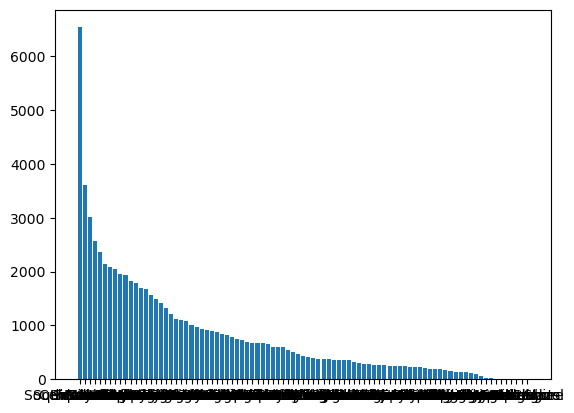

In [41]:
# So South Side Flats is the best (by tree quality over area)
plt.bar(ranked['neighborhood'],ranked['area_score'])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

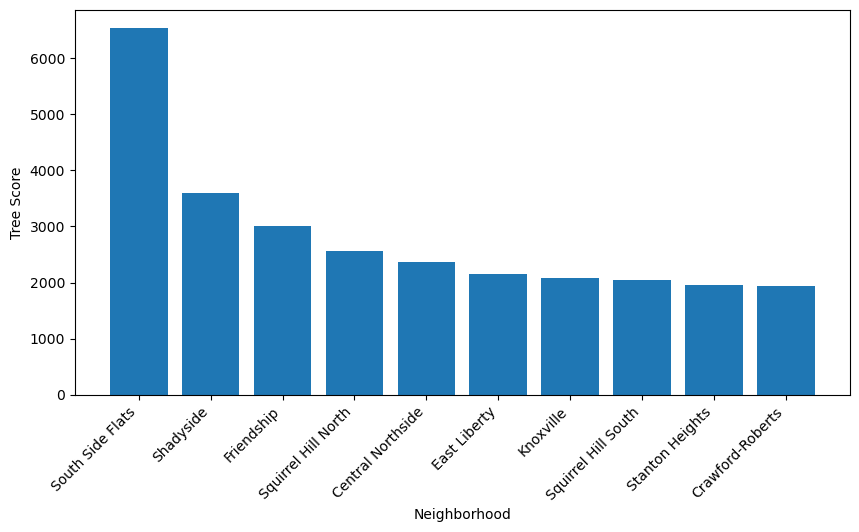

In [42]:
# Ok, now fewer, and more legible.
plt.figure(figsize = (10,5))
plt.xticks(rotation = 45, ha = "right")
plt.bar(ranked['neighborhood'].head(10),ranked['area_score'].head(10))
plt.xlabel("Neighborhood")
plt.ylabel("Tree Score")
plt.show